In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2

In [2]:
dataset_path = "Dataset/UTKFace"

In [3]:
images = []
ages = []
genders = []

IMG_SIZE = 128

for file in os.listdir(dataset_path):

    try:
        age = int(file.split("_")[0])
        gender = int(file.split("_")[1])

        img_path = os.path.join(dataset_path, file)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        images.append(img)
        ages.append(age)
        genders.append(gender)

    except:
        continue

In [4]:
X = np.array(images) / 255.0
y_age = np.array(ages)
y_gender = np.array(genders)

In [5]:
print(X.shape)
print(y_age.shape)
print(y_gender.shape)

(23708, 128, 128, 3)
(23708,)
(23708,)


In [6]:
X_train, X_test, age_train, age_test, gender_train, gender_test = train_test_split(
    X, y_age, y_gender,
    test_size=0.2,
    random_state=42
)

In [7]:
input_layer = Input(shape=(128,128,3))

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_tensor=input_layer
)

x = GlobalAveragePooling2D()(base_model.output)

# Gender branch
gender_output = Dense(1, activation="sigmoid", name="gender")(x)

# Age branch
age_output = Dense(1, activation="linear", name="age")(x)

model = Model(
    inputs=input_layer,
    outputs=[gender_output, age_output]
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_7820\1706441043.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [8]:
model.compile(
    optimizer="adam",
    loss={
        "gender": "binary_crossentropy",
        "age": "mse"
    },
    metrics={
        "gender": "accuracy",
        "age": "mae"
    }
)

In [9]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,226,434 (8.49 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [10]:
history = model.fit(
    X_train,
    {
        "gender": gender_train,
        "age": age_train
    },
    validation_data=(
        X_test,
        {
            "gender": gender_test,
            "age": age_test
        }
    ),
    epochs=1,
    batch_size=32
)

Epoch 1/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 3131s 5s/step - age_loss: 233.6565 - age_mae: 10.5799 - gender_accuracy: 0.6277 - gender_loss: 0.6519 - loss: 234.3083 - val_age_loss: 2714.7390 - val_age_mae: 50.0448 - val_gender_accuracy: 0.5240 - val_gender_loss: 1.5385 - val_loss: 2716.4712
Epoch 2/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 2239s 4s/step - age_loss: 63.2846 - age_mae: 5.7453 - gender_accuracy: 0.6115 - gender_loss: 0.6589 - loss: 63.9435 - val_age_loss: 1001.0518 - val_age_mae: 29.5173 - val_gender_accuracy: 0.5251 - val_gender_loss: 1.0210 - val_loss: 1002.7773
Epoch 3/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 2150s 4s/step - age_loss: 58.6645 - age_mae: 5.5190 - gender_accuracy: 0.6585 - gender_loss: 0.6159 - loss: 59.2804 - val_age_loss: 224.7574 - val_age_mae: 11.4497 - val_gender_accuracy: 0.5276 - val_gender_loss: 1.2866 - val_loss: 226.2872
Epoch 4/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 2052s 3s/step - age_loss: 48.7081 - age_mae: 5.0109 - gender_accuracy: 0.7341 - gender_loss: 0.5208 - loss: 49

In [12]:
model.save("Age_Gender_MobileNetV2.h5")

In [1]:
import tensorflow as tf
model = tf.keras.models.load_model("Age_Gender_MobileNetV2.h5", compile=False)

In [46]:
import cv2
import numpy as np
img = cv2.imread(r"D:\Automatic_facial_image_labelling\Dataset\UTKFace\23_1_0_20170104234542547.jpg.chip.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img = cv2.resize(img,(128,128))
img = img/255.0

img = np.expand_dims(img, axis=0)

In [47]:
pred = model.predict(img)

gender_prob = pred[0][0][0]
age_pred = pred[1][0][0]
print("gender_prob:", gender_prob)

gender = "Female" if gender_prob > 0.5 else "Male"

print("Gender:", gender)
print("Age:", int(age_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
gender_prob: 0.23715593
Gender: Male
Age: 28


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

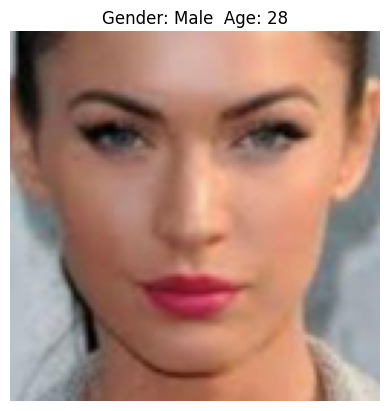

In [48]:
import matplotlib.pyplot as plt
plt.imshow(img[0])
plt.title(f"Gender: {gender}  Age: {int(age_pred)}")
plt.axis("off")